In [27]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

# 1. 데이터 로드
iris = load_iris() # 사이킷런에서 붓꽃데이터를 제공

In [28]:
# 독립, 종속 분리
# 원래는 종속이 필요 없음 => 왜? 비지도
#  =>하는 이유? => 테스트하기 위해
X = iris.data[:, 2:4] # 시각화를 위해
y = iris.target


In [29]:
# test_size=0.2는 전체의 20%를 테스트용으로 쓰겠다는 의미
# random_state는 실행할 때마다 결과가 달라지지 않도록 고정하는 값
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [30]:
# 스케일링
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [31]:
# 그룹을 3개로 나눔(붓꽃 종류가 3개라서)
# n_init : 몇 번실행할 건지를 정해서 오차가 취소가 되는 결과를 학습 => 응집도를 확인
model = KMeans(n_clusters=3,random_state=42, n_init=10)
model.fit(X_train_scaled )

c:\Users\C603\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,n_clusters,3
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [ ]:
# 성능은 항상 음수. 이유 : sklearn에서 용집도는 음수로 표시
# 용집도가 좋음 => 잘뭉쳐있음 => 숫자가 큼(-1~-100)
accuracy = model .score(X_test_scaled, y_test)
print(f"테스트 데이터 정확도: {accuracy:.2f}")

테스트 데이터 정확도: -3.18


In [33]:
# 시각화 범위 설정 (스케일링 된 데이터 기준)
# -0.5, +0.5는 그래프 여백
x_min, x_max = X_train_scaled[:, 0].min() - 0.5, X_train_scaled[:, 0].max() + 0.5
y_min, y_max = X_train_scaled[:, 1].min() - 0.5, X_train_scaled[:, 1].max() + 0.5
hh = 0.02
xx, yy = np.meshgrid(np.arange(x_min, x_max, hh),
                     np.arange(y_min, y_max, hh))

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

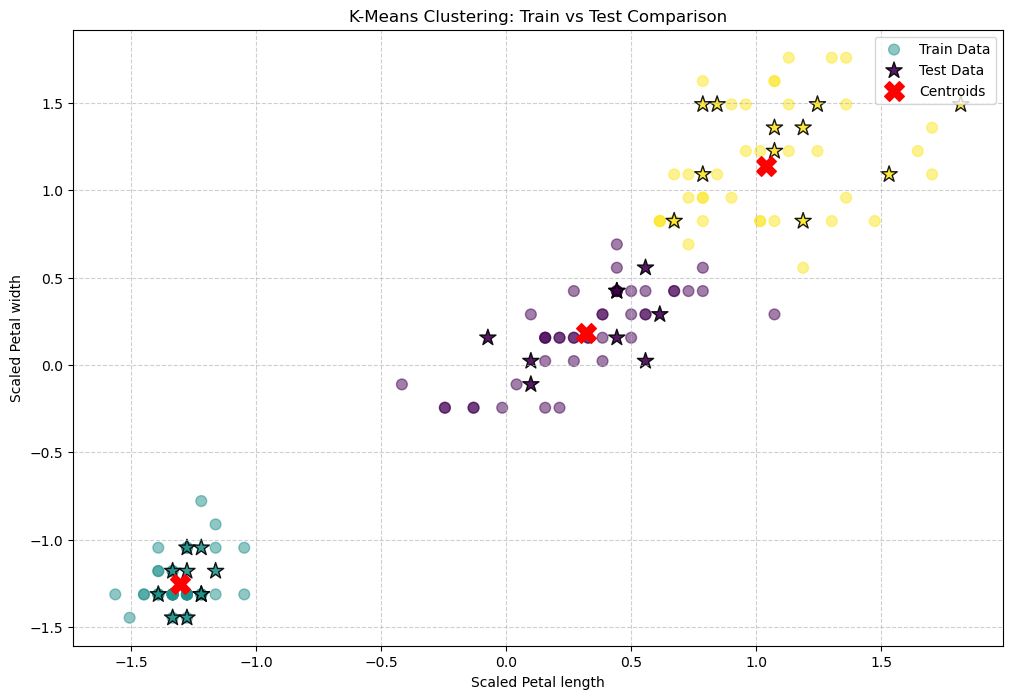

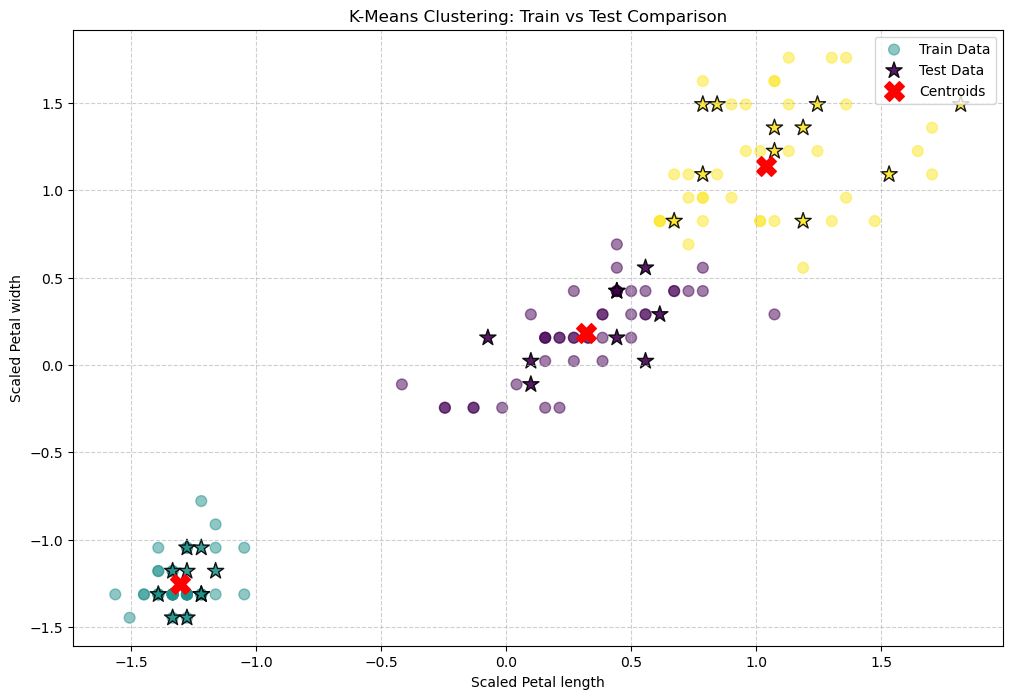

In [34]:
train_labels = model.labels_            # 훈련 데이터의 군집 결과
test_labels = model.predict(X_test_scaled) # 테스트 데이터의 군집 결과 (중요!)
centroids = model.cluster_centers_         # 중심점

# 시각화
plt.figure(figsize=(12, 8))

# [훈련 데이터] 동그라미('o')로 표시
plt.scatter(X_train_scaled[:, 0], X_train_scaled[:, 1], 
            c=train_labels, cmap='viridis', s=60, alpha=0.5, 
            marker='o', label='Train Data')

# [테스트 데이터] 별 모양('*')으로 표시 (훈련 데이터와 같은 색상 체계 적용)
plt.scatter(X_test_scaled[:, 0], X_test_scaled[:, 1], 
            c=test_labels, cmap='viridis', s=150, alpha=0.9, 
            marker='*', edgecolor='black', label='Test Data')

# [중심점] 빨간색 X로 표시
plt.scatter(centroids[:, 0], centroids[:, 1], 
            c='red', marker='X', s=200, label='Centroids')

# 그래프 설정
plt.xlabel('Scaled Petal length')
plt.ylabel('Scaled Petal width')
plt.title('K-Means Clustering: Train vs Test Comparison')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()
train_labels = model.labels_               # 훈련 데이터의 군집 결과
test_labels = model.predict(X_test_scaled) # 테스트 데이터의 군집 결과 (중요!)
centroids = model.cluster_centers_         # 중심점

# 시각화
plt.figure(figsize=(12, 8))

# [훈련 데이터] 동그라미('o')로 표시
plt.scatter(X_train_scaled[:, 0], X_train_scaled[:, 1], 
            c=train_labels, cmap='viridis', s=60, alpha=0.5, 
            marker='o', label='Train Data')

# [테스트 데이터] 별 모양('*')으로 표시 (훈련 데이터와 같은 색상 체계 적용)
plt.scatter(X_test_scaled[:, 0], X_test_scaled[:, 1], 
            c=test_labels, cmap='viridis', s=150, alpha=0.9, 
            marker='*', edgecolor='black', label='Test Data')

# [중심점] 빨간색 X로 표시
plt.scatter(centroids[:, 0], centroids[:, 1], 
            c='red', marker='X', s=200, label='Centroids')

# 그래프 설정
plt.xlabel('Scaled Petal length')
plt.ylabel('Scaled Petal width')
plt.title('K-Means Clustering: Train vs Test Comparison')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()